# **Question No. 03**

In [1]:
# =========================
# Cell 1: Environment Setup
# =========================
import os, sys, math, time, glob, shutil, random, re, zipfile, importlib
from pathlib import Path

import torch
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", device)
!nvidia-smi

# Minimal deps; scikit-image for SSIM/PSNR, albumentations for aug, OpenCV headless for Colab
%pip -q install -U kaggle scikit-image==0.24.0 albumentations==1.4.7 opencv-python-headless==4.10.0.84

PyTorch: 2.8.0+cu126
Device: cuda
Sun Nov  2 07:05:01 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   67C    P8             11W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-------------

In [2]:
# =========================
# Cell 2: Quick Mode Config
# =========================
QUICK = True

if QUICK:
    EPOCHS = 8
    IMG_SIZE = 256          # <-- set to 256 (multiple of 2^8)
    MAX_TRAIN_PAIRS = 1200
    MAX_VAL_PAIRS   = 200
    BATCH_SIZE = 8
    LAMBDA_L1 = 100.0
    LAMBDA_P  = 5.0
    PERCEPTUAL_EVERY = 3
else:
    EPOCHS = 100
    IMG_SIZE = 256
    MAX_TRAIN_PAIRS = None
    MAX_VAL_PAIRS   = None
    BATCH_SIZE = 8
    LAMBDA_L1 = 100.0
    LAMBDA_P  = 10.0
    PERCEPTUAL_EVERY = 1

In [3]:
# ===========================================
# Cell 3: Download Dataset (Kaggle CLI route)
# ===========================================
import json

# 1) Ensure Kaggle credentials are set (one-time upload)
os.makedirs("/root/.kaggle", exist_ok=True)
if not os.path.exists("/root/.kaggle/kaggle.json"):
    from google.colab import files
    print("Please upload your kaggle.json (Kaggle → Account → Create New Token)")
    uploaded = files.upload()
    if "kaggle.json" not in uploaded:
        raise RuntimeError("kaggle.json not uploaded. Re-run this cell and upload the file.")
    with open("/root/.kaggle/kaggle.json", "wb") as f:
        f.write(uploaded["kaggle.json"])
    os.chmod("/root/.kaggle/kaggle.json", 0o600)

# 2) Download & unzip dataset
DATASET_REF = "almightyj/person-face-sketches"
os.makedirs("kaggle_data", exist_ok=True)
!kaggle datasets download -d $DATASET_REF -p ./kaggle_data -q

for z in glob.glob("kaggle_data/*.zip"):
    print("Unzipping:", z)
    with zipfile.ZipFile(z, "r") as Z:
        Z.extractall("kaggle_data")

root = Path("kaggle_data")
print("Path to dataset files:", root.resolve())

# 3) Pair sketches↔faces by filename stem, tolerant to *_sketch etc.
IMG_EXT = {".png",".jpg",".jpeg",".bmp",".webp"}

def index_images(folder: Path):
    files = []
    for ext in IMG_EXT:
        files += glob.glob(str(folder / f"**/*{ext}"), recursive=True)
    by_stem = {}
    for p in files:
        stem = Path(p).stem.lower()
        by_stem[stem] = p
    return by_stem

candidates = [p for p in root.rglob("*") if p.is_dir()]
sketch_dirs = [d for d in candidates if re.search(r"sketch", d.name, re.I)]
face_dirs   = [d for d in candidates if re.search(r"(photo|face|image)", d.name, re.I)]
if not sketch_dirs or not face_dirs:
    # fallback: use root for both (handles datasets placing all images in one folder)
    sketch_dirs = [root]
    face_dirs   = [root]

sk_map, fa_map = {}, {}
for d in sketch_dirs: sk_map.update(index_images(d))
for d in face_dirs:   fa_map.update(index_images(d))

pairs = []
for stem, spath in sk_map.items():
    candidates = [stem,
                  stem.replace("_sketch",""),
                  stem.replace("-sketch",""),
                  stem.replace("sketch","")]
    match = None
    for c in candidates:
        if c in fa_map:
            match = fa_map[c]; break
    if match:
        pairs.append((spath, match))

print(f"Total pairs found: {len(pairs)}")
assert len(pairs) >= 100, "Not enough paired data found—open dataset structure and verify folder names."

# Train/Val split + optional cap in Quick Mode
random.seed(42); random.shuffle(pairs)
split = int(0.9 * len(pairs))
train_pairs = pairs[:split]
val_pairs   = pairs[split:]

if QUICK:
    if MAX_TRAIN_PAIRS: train_pairs = train_pairs[:min(MAX_TRAIN_PAIRS, len(train_pairs))]
    if MAX_VAL_PAIRS:   val_pairs   = val_pairs[:min(MAX_VAL_PAIRS, len(val_pairs))]

print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)}")

Please upload your kaggle.json (Kaggle → Account → Create New Token)


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/almightyj/person-face-sketches
License(s): CC0-1.0
Unzipping: kaggle_data/person-face-sketches.zip
Path to dataset files: /content/kaggle_data
Total pairs found: 21679
Train: 1200 | Val: 200


In [4]:
# =======================================
# Cell 4: Datasets & Dataloaders (Augs)
# =======================================
import cv2
import numpy as np
import albumentations as A
from torch.utils.data import Dataset, DataLoader

train_tfms = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(IMG_SIZE, IMG_SIZE, border_mode=cv2.BORDER_REFLECT_101),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=10,
                       border_mode=cv2.BORDER_REFLECT_101, p=0.4),
])
val_tfms = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(IMG_SIZE, IMG_SIZE, border_mode=cv2.BORDER_REFLECT_101),
])

def to_tensor(img):
    # HWC BGR -> CHW RGB in [-1,1]
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32) / 127.5 - 1.0
    return torch.from_numpy(img.transpose(2,0,1))

class Sketch2Face(Dataset):
    def __init__(self, pairs, train=True):
        self.pairs = pairs
        self.train = train
        self.tfms  = train_tfms if train else val_tfms
    def __len__(self): return len(self.pairs)
    def __getitem__(self, idx):
        spath, fpath = self.pairs[idx]
        s = cv2.imread(spath); f = cv2.imread(fpath)
        if s is None or f is None:
            raise RuntimeError(f"Bad file: {spath} or {fpath}")
        augmented = self.tfms(image=s, mask=f)  # share aug params
        s_aug = augmented["image"]; f_aug = augmented["mask"]
        return to_tensor(s_aug), to_tensor(f_aug), spath, fpath

train_ds = Sketch2Face(train_pairs, train=True)
val_ds   = Sketch2Face(val_pairs,   train=False)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=2, pin_memory=True, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True, drop_last=False)

len(train_dl), len(val_dl)

(150, 25)

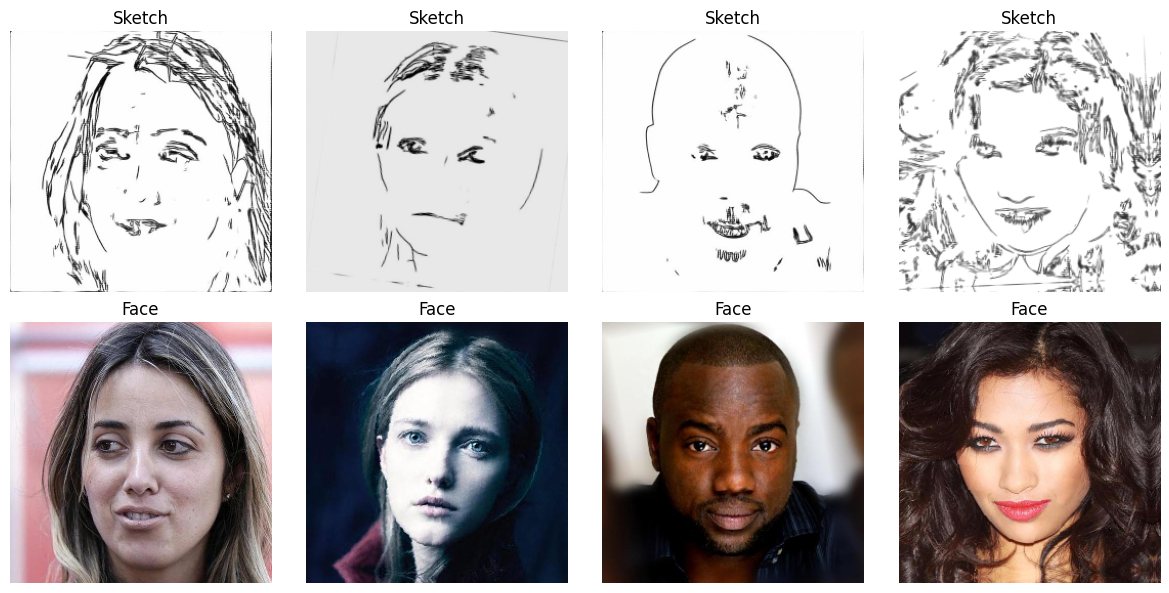

In [5]:
# =======================================
# Cell 5: Visualize a few paired samples
# =======================================
import matplotlib.pyplot as plt

def denorm(x):  # [C,H,W] [-1,1] -> [0,1]
    return (x.clamp(-1,1) + 1)/2

batch = next(iter(train_dl))
s, f, sp, fp = batch
grid = min(4, s.size(0))
plt.figure(figsize=(12,6))
for i in range(grid):
    plt.subplot(2, grid, i+1)
    plt.imshow(denorm(s[i]).permute(1,2,0).cpu().numpy())
    plt.title("Sketch"); plt.axis('off')
    plt.subplot(2, grid, grid+i+1)
    plt.imshow(denorm(f[i]).permute(1,2,0).cpu().numpy())
    plt.title("Face"); plt.axis('off')
plt.tight_layout(); plt.show()

In [6]:
# ===================================
# Cell 6: Generator & Discriminator
# ===================================
import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c, norm=True):
        super().__init__()
        layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)]
        if norm: layers += [nn.BatchNorm2d(out_c)]
        layers += [nn.LeakyReLU(0.2, inplace=True)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

class DeconvBlock(nn.Module):
    def __init__(self, in_c, out_c, dropout=False):
        super().__init__()
        layers = [nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=False),
                  nn.BatchNorm2d(out_c),
                  nn.ReLU(True)]
        if dropout: layers += [nn.Dropout(0.5)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

BASE_CH = 48 if QUICK else 64

class UNetGenerator(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, base=BASE_CH):
        super().__init__()
        self.down1 = ConvBlock(in_ch,   base,   norm=False)
        self.down2 = ConvBlock(base,    base*2)
        self.down3 = ConvBlock(base*2,  base*4)
        self.down4 = ConvBlock(base*4,  base*8)
        self.down5 = ConvBlock(base*8,  base*8)
        self.down6 = ConvBlock(base*8,  base*8)
        self.down7 = ConvBlock(base*8,  base*8)
        self.down8 = ConvBlock(base*8,  base*8, norm=False)

        self.up1 = DeconvBlock(base*8, base*8, dropout=True)
        self.up2 = DeconvBlock(base*16, base*8, dropout=True)
        self.up3 = DeconvBlock(base*16, base*8, dropout=True)
        self.up4 = DeconvBlock(base*16, base*8)
        self.up5 = DeconvBlock(base*16, base*4)
        self.up6 = DeconvBlock(base*8,  base*2)
        self.up7 = DeconvBlock(base*4,  base)
        self.up8 = nn.Sequential(nn.ConvTranspose2d(base*2, out_ch, 4, 2, 1), nn.Tanh())

    def forward(self, x):
        d1 = self.down1(x); d2 = self.down2(d1); d3 = self.down3(d2); d4 = self.down4(d3)
        d5 = self.down5(d4); d6 = self.down6(d5); d7 = self.down7(d6); d8 = self.down8(d7)
        u1 = self.up1(d8)
        u2 = self.up2(torch.cat([u1, d7], dim=1))
        u3 = self.up3(torch.cat([u2, d6], dim=1))
        u4 = self.up4(torch.cat([u3, d5], dim=1))
        u5 = self.up5(torch.cat([u4, d4], dim=1))
        u6 = self.up6(torch.cat([u5, d3], dim=1))
        u7 = self.up7(torch.cat([u6, d2], dim=1))
        out = self.up8(torch.cat([u7, d1], dim=1))
        return out

class PatchDiscriminator(nn.Module):
    def __init__(self, in_ch=3, cond_ch=3, base=64):
        super().__init__()
        ch = in_ch + cond_ch
        self.seq = nn.Sequential(
            nn.Conv2d(ch, base, 4, 2, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(base, base*2, 4, 2, 1, bias=False), nn.BatchNorm2d(base*2), nn.LeakyReLU(0.2, True),
            nn.Conv2d(base*2, base*4, 4, 2, 1, bias=False), nn.BatchNorm2d(base*4), nn.LeakyReLU(0.2, True),
            nn.Conv2d(base*4, base*8, 4, 1, 1, bias=False), nn.BatchNorm2d(base*8), nn.LeakyReLU(0.2, True),
            nn.Conv2d(base*8, 1, 4, 1, 1)
        )
    def forward(self, x, cond):
        return self.seq(torch.cat([x, cond], dim=1))

G = UNetGenerator().to(device)
D = PatchDiscriminator().to(device)

print("G params (M):", round(sum(p.numel() for p in G.parameters())/1e6, 2))
print("D params (M):", round(sum(p.numel() for p in D.parameters())/1e6, 2))

G params (M): 30.61
D params (M): 2.77


In [7]:
# ======================================
# Cell 7: Losses, Opt, AMP, Perceptual
# ======================================
import torch.nn.functional as F
import torch.nn as nn
from torchvision.models import vgg19, VGG19_Weights
from torch.amp import GradScaler, autocast

# Adversarial criterion
bce = nn.BCEWithLogitsLoss()

# Perceptual (VGG19 feature L1)
class VGGPerceptual(nn.Module):
    def __init__(self, layers=(2,7,12,21,30)):
        super().__init__()
        vgg = vgg19(weights=VGG19_Weights.DEFAULT).features.eval()
        for p in vgg.parameters(): p.requires_grad=False
        self.vgg = vgg.to(device)
        self.layers = set(layers)
    def forward(self, x, y):
        def norm_im(z):
            z = (z + 1)/2
            mean = torch.tensor([0.485,0.456,0.406], device=z.device)[None,:,None,None]
            std  = torch.tensor([0.229,0.224,0.225], device=z.device)[None,:,None,None]
            return (z - mean)/std
        x, y = norm_im(x), norm_im(y)
        loss = 0.0
        h1, h2 = x, y
        for i, layer in enumerate(self.vgg):
            h1 = layer(h1); h2 = layer(h2)
            if i in self.layers:
                loss = loss + F.l1_loss(h1, h2)
        return loss

percep = VGGPerceptual()

# Optimizers & AMP scalers
lrG, lrD = 2e-4, 2e-4
betas = (0.5, 0.999)
optG = torch.optim.Adam(G.parameters(), lr=lrG, betas=betas)
optD = torch.optim.Adam(D.parameters(), lr=lrD, betas=betas)
scalerG = GradScaler('cuda', enabled=(device.type=='cuda'))
scalerD = GradScaler('cuda', enabled=(device.type=='cuda'))

# Pull from config
lambda_L1 = LAMBDA_L1
lambda_P  = LAMBDA_P
perceptual_every = PERCEPTUAL_EVERY

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:04<00:00, 126MB/s]


In [8]:
# ===================================
# Cell 8: Train Utils (logs & saves)
# ===================================
from torchvision.utils import make_grid, save_image

def denorm_batch(x):  # [B,C,H,W] [-1,1] -> [0,1]
    return (x.clamp(-1,1)+1)/2

os.makedirs("checkpoints", exist_ok=True)
os.makedirs("samples/train", exist_ok=True)
os.makedirs("samples/val", exist_ok=True)
LOG_TXT = "train_log.txt"
LOG_CSV = "train_losses.csv"

# Reset logs
with open(LOG_TXT, "w") as f: f.write("Conditional GAN (Sketch->Face) Training Log\n")
with open(LOG_CSV, "w") as f: f.write("epoch,step,loss_D,loss_G,adv_G,rec_L1,percep\n")

def write_log(msg):
    print(msg)
    with open(LOG_TXT, "a") as f:
        f.write(msg + "\n")

@torch.no_grad()
def sample_and_save(tag, modelG, loader, ep, max_batches=1):
    modelG.eval()
    cnt = 0
    for sk, real, *_ in loader:
        sk = sk.to(device)
        fake = modelG(sk)
        grid = torch.cat([sk[:4], real[:4].to(device), fake[:4]], dim=0)
        save_image(denorm_batch(grid), f"samples/{tag}/ep{ep:03d}_b{cnt:03d}.png", nrow=4)
        cnt += 1
        if cnt >= max_batches: break
    modelG.train()

def save_ckpt(e):
    torch.save({"G": G.state_dict(),
                "D": D.state_dict(),
                "optG": optG.state_dict(),
                "optD": optD.state_dict(),
                "epoch": e}, f"checkpoints/ckpt_ep{e:03d}.pt")

In [9]:
# =========================
# Cell 9: Training Loop
# =========================
from tqdm.auto import tqdm

CLIP_NORM = 1.0
current_epoch = 0

for epoch in range(EPOCHS):
    current_epoch = epoch + 1
    G.train(); D.train()
    pbar = tqdm(train_dl, desc=f"[cGAN] Epoch {current_epoch}/{EPOCHS}")
    for step, (sk, real, *_ ) in enumerate(pbar, 1):
        sk   = sk.to(device, non_blocking=True)
        real = real.to(device, non_blocking=True)

        # ---- Train D ----
        with autocast('cuda', enabled=(device.type=='cuda')):
            fake_det = G(sk).detach()
            pred_real = D(real, sk)
            pred_fake = D(fake_det, sk)
            loss_D = 0.5*(bce(pred_real, torch.ones_like(pred_real)) +
                          bce(pred_fake, torch.zeros_like(pred_fake)))
        optD.zero_grad(set_to_none=True)
        scalerD.scale(loss_D).backward()
        scalerD.unscale_(optD)
        torch.nn.utils.clip_grad_norm_(D.parameters(), CLIP_NORM)
        scalerD.step(optD); scalerD.update()

        # ---- Train G ----
        with autocast('cuda', enabled=(device.type=='cuda')):
            fake = G(sk)
            adv_G  = bce(D(fake, sk), torch.ones_like(D(fake, sk)))
            rec_L1 = F.l1_loss(fake, real)
            if (step % perceptual_every) == 0:
                per = percep(fake, real)
            else:
                per = torch.tensor(0.0, device=device)
            loss_G = adv_G + lambda_L1*rec_L1 + lambda_P*per

        optG.zero_grad(set_to_none=True)
        scalerG.scale(loss_G).backward()
        scalerG.unscale_(optG)
        torch.nn.utils.clip_grad_norm_(G.parameters(), CLIP_NORM)
        scalerG.step(optG); scalerG.update()

        pbar.set_postfix(D=float(loss_D.item()), G=float(loss_G.item()))

        # CSV log every 50 steps
        if step % 50 == 0:
            with open(LOG_CSV, "a") as f:
                f.write(f"{current_epoch},{step},{loss_D.item():.6f},{loss_G.item():.6f},{adv_G.item():.6f},{rec_L1.item():.6f},{per.item():.6f}\n")

    # End epoch: samples, ckpt, txt log
    sample_and_save("train", G, train_dl, current_epoch, max_batches=1)
    sample_and_save("val",   G, val_dl,   current_epoch, max_batches=1)
    save_ckpt(current_epoch)
    write_log(f"Epoch {current_epoch}: D={loss_D.item():.4f} G={loss_G.item():.4f} | adv={adv_G.item():.4f} L1={rec_L1.item():.4f} P={per.item():.4f}")

[cGAN] Epoch 1/8:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 1: D=0.3548 G=175.0970 | adv=4.4061 L1=0.4607 P=24.9238


[cGAN] Epoch 2/8:   0%|          | 0/150 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x780027fb8180>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x780027fb8180>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 2: D=0.3478 G=140.9747 | adv=3.3867 L1=0.3715 P=20.0875


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x780027fb8180>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x780027fb8180>
Exception ignored in: Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x780027fb8180>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    
self._shutdown_workers(

Epoch 7: D=0.3972 G=137.8503 | adv=1.6003 L1=0.3577 P=20.0956


[cGAN] Epoch 8/8:   0%|          | 0/150 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x780027fb8180>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x780027fb8180>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x780027fb8180

Epoch 8: D=0.4339 G=128.7426 | adv=1.6833 L1=0.3240 P=18.9324


,epoch,step,loss_D,loss_G,adv_G,rec_L1,percep
19,7,100,0.553175,40.143429,2.916574,0.372269,0.000000
20,7,150,0.397155,137.850311,1.600346,0.357717,20.095650
21,8,50,0.438846,37.632763,1.876142,0.357566,0.000000
22,8,100,0.165448,39.500744,2.945912,0.365548,0.000000
23,8,150,0.433876,128.742569,1.683279,0.323973,18.932396


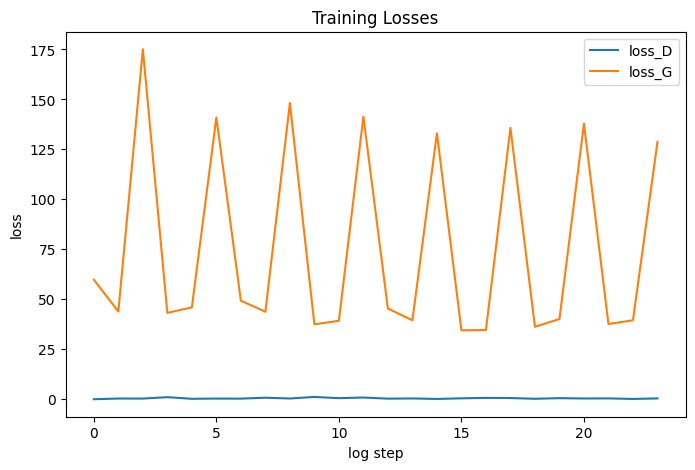

Summary appended to train_log.txt


In [10]:
# ============================
# Cell 10: Plot & TXT summary
# ============================
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(LOG_CSV)
display(df.tail())

plt.figure(figsize=(8,5))
plt.plot(df['loss_D'], label='loss_D')
plt.plot(df['loss_G'], label='loss_G')
plt.legend(); plt.title("Training Losses"); plt.xlabel("log step"); plt.ylabel("loss")
plt.show()

with open(LOG_TXT, "a") as f:
    f.write("\nSummary:\n")
    if len(df) > 0:
        f.write(f"Min loss_G: {df['loss_G'].min():.4f} | Min loss_D: {df['loss_D'].min():.4f}\n")
        f.write(f"Final row: {df.iloc[-1].to_dict()}\n")
print("Summary appended to", LOG_TXT)

In [11]:
# =====================================
# Cell 11: SSIM / PSNR (Validation)
# =====================================
import numpy as np
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

@torch.no_grad()
def evaluate_ssim_psnr(modelG, loader, max_batches=10):
    modelG.eval()
    ssim_scores, psnr_scores = [], []
    cnt = 0
    for sk, real, *_ in loader:
        sk, real = sk.to(device), real.to(device)
        fake = modelG(sk)
        for i in range(fake.size(0)):
            f = (fake[i].clamp(-1,1).cpu().numpy().transpose(1,2,0)+1)/2
            r = (real[i].clamp(-1,1).cpu().numpy().transpose(1,2,0)+1)/2
            ssim_scores.append(ssim(f, r, channel_axis=2, data_range=1.0))
            psnr_scores.append(psnr(r, f, data_range=1.0))
        cnt += 1
        if cnt >= max_batches: break
    return float(np.mean(ssim_scores)), float(np.mean(psnr_scores))

mean_ssim, mean_psnr = evaluate_ssim_psnr(G, val_dl, max_batches=10)
print(f"Validation — SSIM: {mean_ssim:.4f} | PSNR: {mean_psnr:.2f} dB")

with open(LOG_TXT, "a") as f:
    f.write(f"Validation: SSIM={mean_ssim:.4f}, PSNR={mean_psnr:.2f} dB\n")

Validation — SSIM: 0.2806 | PSNR: 11.55 dB


Upload a sketch image (PNG/JPG).


Saving input.jpg to input (1).jpg


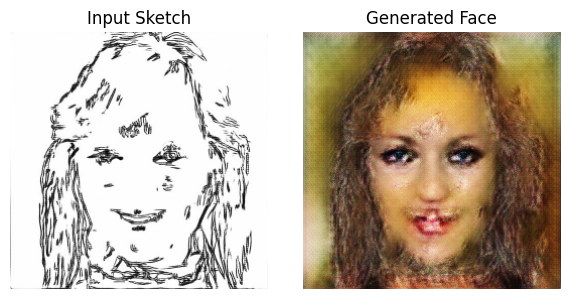

Saved: gen_input (1).png


In [14]:
# ==========================================
# Cell 12: Inference on Your Sketch (Upload)
# ==========================================
from google.colab import files
import numpy as np, cv2, torch
import matplotlib.pyplot as plt
from torchvision.utils import save_image

def letterbox_to_square_rgb(im, size=IMG_SIZE):
    # im: RGB uint8 HxWx3 (handles RGBA -> RGB as well)
    if im.ndim == 2:  # grayscale -> RGB
        im = np.stack([im, im, im], axis=-1)
    if im.shape[2] == 4:  # RGBA -> RGB
        im = im[:, :, :3]
    h, w = im.shape[:2]
    scale = size / max(h, w)
    nh, nw = int(h * scale), int(w * scale)
    imr = cv2.resize(im, (nw, nh), interpolation=cv2.INTER_AREA)
    canvas = np.zeros((size, size, 3), dtype=np.uint8)
    top = (size - nh) // 2
    left = (size - nw) // 2
    canvas[top:top + nh, left:left + nw] = imr
    return canvas

def load_img_to_tensor(pth, size=IMG_SIZE):
    im = cv2.imread(pth, cv2.IMREAD_UNCHANGED)
    if im is None:
        raise ValueError(f"Could not read image: {pth}")
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB) if im.ndim == 3 else im
    canvas = letterbox_to_square_rgb(im, size=size)
    tens = torch.from_numpy(canvas.astype(np.float32) / 127.5 - 1.0).permute(2, 0, 1).unsqueeze(0)
    return tens  # float32 in [-1,1]

print("Upload a sketch image (PNG/JPG).")
up = files.upload()

for name in up.keys():
    path = name
    sk_t = load_img_to_tensor(path).to(device)

    # Generate (AMP is fine; we’ll cast to float32 for plotting)
    with torch.no_grad(), torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
        fake = G(sk_t)

    # Denorm to [0,1] and cast to float32 for matplotlib
    sk_v = (sk_t[0].clamp(-1, 1) + 1) / 2
    fk_v = (fake[0].clamp(-1, 1) + 1) / 2

    sk_np = sk_v.permute(1, 2, 0).detach().cpu().to(torch.float32).numpy()
    fk_np = fk_v.permute(1, 2, 0).detach().cpu().to(torch.float32).numpy()

    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1); plt.imshow(sk_np); plt.title("Input Sketch"); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(fk_np); plt.title("Generated Face"); plt.axis('off')
    plt.tight_layout(); plt.show()

    out_path = f"gen_{Path(path).stem}.png"
    # save_image expects CHW tensor in [0,1] float32 — ensure dtype
    save_image(fk_v.to(torch.float32), out_path)
    print("Saved:", out_path)

In [17]:
def load_ckpt(path="checkpoints/ckpt_ep008.pt"):
    ck = torch.load(path, map_location=device)
    G.load_state_dict(ck["G"]); D.load_state_dict(ck["D"])
    optG.load_state_dict(ck["optG"]); optD.load_state_dict(ck["optD"])
    print("Loaded:", path)

# Example:
load_ckpt("checkpoints/ckpt_ep008.pt")

Loaded: checkpoints/ckpt_ep008.pt
